In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

PROJECT_DIR = Path.cwd().parent      
DATA_PROCESSED = PROJECT_DIR / "data_processed"
OUTPUT = PROJECT_DIR / "outputs"

df_vad = pd.read_csv(DATA_PROCESSED / "reddit_with_vad.csv")
df_tox = pd.read_csv(DATA_PROCESSED / "reddit_with_toxicity.csv")
topics_df = pd.read_csv(OUTPUT / "lda_toxic_topics.csv")
topics_year_df = pd.read_csv(OUTPUT / "lda_toxic_topics_by_year.csv")

df_vad.head(), df_tox.head()


(                                                body          created_utc  \
 0  Done - your wish is our command.  Graves shall...  2017-04-01 16:01:43   
 1  I don't play league but goddam it if I'm not g...  2017-04-01 03:56:12   
 2         http://imgur.com/a/8F7c6 WE DID IT REDDIT!  2017-04-01 04:01:06   
 3                                        Seems legit  2017-04-01 00:55:50   
 4  Graves no cigar, graves in peril, not to worry...  2017-04-01 01:19:17   
 
    score           created_dt        date  year  month year_month  \
 0   2022  2017-04-01 16:01:43  2017-04-01  2017      4    2017-04   
 1   4183  2017-04-01 03:56:12  2017-04-01  2017      4    2017-04   
 2    267  2017-04-01 04:01:06  2017-04-01  2017      4    2017-04   
 3    978  2017-04-01 00:55:50  2017-04-01  2017      4    2017-04   
 4    670  2017-04-01 01:19:17  2017-04-01  2017      4    2017-04   
 
                                           text_clean  \
 0  done your wish is our command graves shall onc.

In [2]:
sent_year = (
    df_vad.groupby("year")[["vad_valence_mean", "vad_arousal_mean", "vad_dominance_mean"]]
           .mean()
           .reset_index()
)

sent_year


,year,vad_valence_mean,vad_arousal_mean,vad_dominance_mean
0,2015,0.159194,0.017050,0.063151
1,2016,0.130773,0.042561,0.051405
2,2017,0.112470,0.045354,0.052723
3,2018,0.131145,0.018157,0.050956
4,2019,0.164347,0.011304,0.053145
5,2020,0.154233,0.022064,0.059367
6,2021,0.160539,0.017087,0.059864
7,2022,0.162328,0.029003,0.071184
8,2024,0.099469,0.062948,0.106309
9,2025,0.157489,0.000308,0.071219


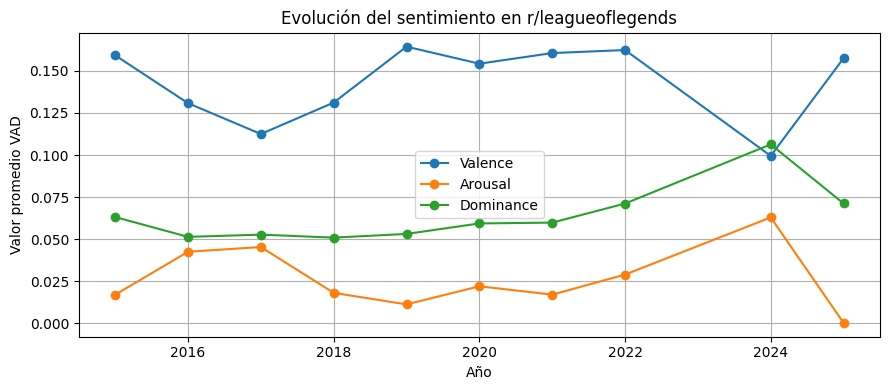

In [3]:
plt.figure(figsize=(9,4))
plt.plot(sent_year["year"], sent_year["vad_valence_mean"], marker="o", label="Valence")
plt.plot(sent_year["year"], sent_year["vad_arousal_mean"], marker="o", label="Arousal")
plt.plot(sent_year["year"], sent_year["vad_dominance_mean"], marker="o", label="Dominance")
plt.title("Evolución del sentimiento en r/leagueoflegends")
plt.xlabel("Año"); plt.ylabel("Valor promedio VAD")
plt.grid(True); plt.legend(); plt.tight_layout()
plt.show()


In [4]:
tox_year = (
    df_tox.groupby("year")[["tox_ratio", "tox_adv_score_norm"]]
          .mean()
          .reset_index()
)
tox_year


,year,tox_ratio,tox_adv_score_norm
0,2015,0.021547,0.048926
1,2016,0.030924,0.077167
2,2017,0.020186,0.049297
3,2018,0.021777,0.051514
4,2019,0.015450,0.036645
5,2020,0.016321,0.039670
6,2021,0.014388,0.034202
7,2022,0.018544,0.043675
8,2024,0.024179,0.061068
9,2025,0.009132,0.021759


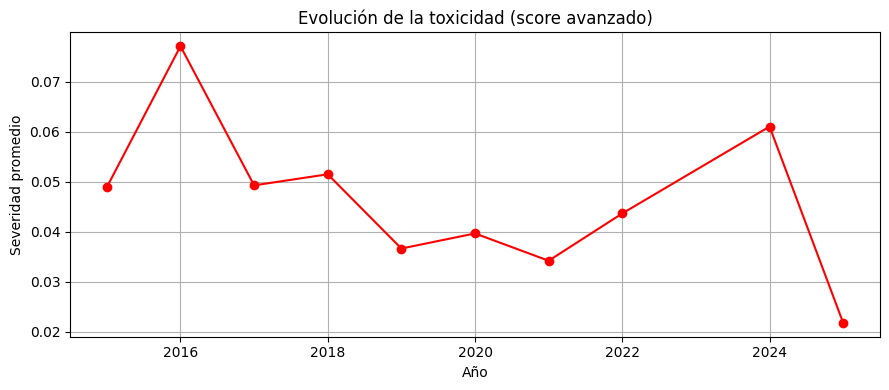

In [5]:
plt.figure(figsize=(9,4))
plt.plot(tox_year["year"], tox_year["tox_adv_score_norm"], marker="o", color="red")
plt.title("Evolución de la toxicidad (score avanzado)")
plt.xlabel("Año"); plt.ylabel("Severidad promedio")
plt.grid(True); plt.tight_layout()
plt.show()


In [6]:
df_tox["tox_has_toxic"] = df_tox["tox_has_toxic"].astype(int)

tox_pct = (
    df_tox.groupby("year")["tox_has_toxic"].mean().reset_index()
)
tox_pct


,year,tox_has_toxic
0,2015,0.125448
1,2016,0.133690
2,2017,0.109677
3,2018,0.119101
4,2019,0.080856
5,2020,0.086365
6,2021,0.082926
7,2022,0.108936
8,2024,0.132653
9,2025,0.068251


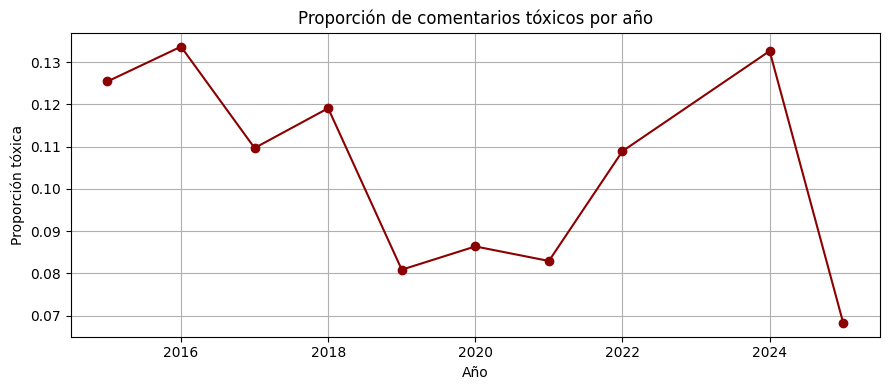

In [7]:
plt.figure(figsize=(9,4))
plt.plot(tox_pct["year"], tox_pct["tox_has_toxic"], marker="o", color="darkred")
plt.title("Proporción de comentarios tóxicos por año")
plt.xlabel("Año"); plt.ylabel("Proporción tóxica")
plt.grid(True); plt.tight_layout()
plt.show()


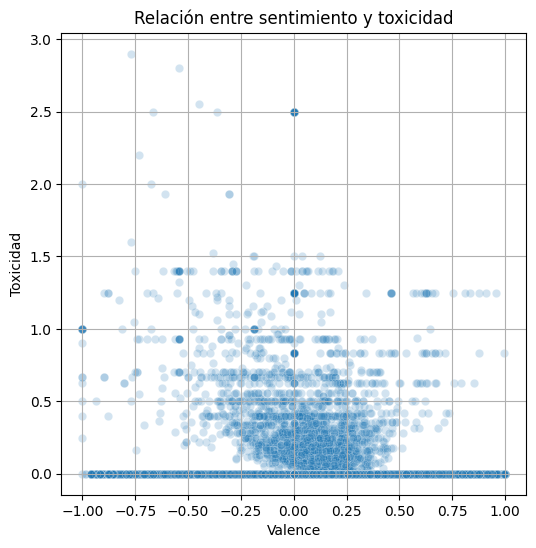

In [8]:
plt.figure(figsize=(6,6))
sns.scatterplot(
    x=df_tox["vad_valence_mean"],
    y=df_tox["tox_adv_score_norm"],
    alpha=0.2
)
plt.xlabel("Valence"); plt.ylabel("Toxicidad")
plt.title("Relación entre sentimiento y toxicidad")
plt.grid(True)
plt.show()


In [9]:
topics_pivot = topics_df.pivot(index="topic_id", columns="rank", values="term")
topics_pivot


rank,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
topic_id,,,,,,,,,,,,,,,
0,shit,game,like,play,playing,just,games,league,ranked,hard,stop,time,ll,season,fun
1,fucking,riot,stupid,just,way,league,like,make,did,really,game,legends,skins,skin,let
2,man,fuck,t1,team,lol,fucking,faker,na,sad,shit,guma,org,gonna,just,honestly
3,fucking,fuck,good,oh,actually,god,time,actual,got,like,wait,riot,damn,did,imagine
4,fuck,trash,just,talk,game,hope,say,like,win,going,want,make,did,guy,doesn
5,just,lmao,troll,useless,garbage,yasuo,doing,play,player,int,guy,jungle,people,uninstall,toxic
6,shit,holy,seen,fucking,good,looks,awesome,thats,amazing,cool,series,dude,love,year,best
7,people,shit,like,just,game,players,know,really,games,think,play,bitch,lane,adc,enemy


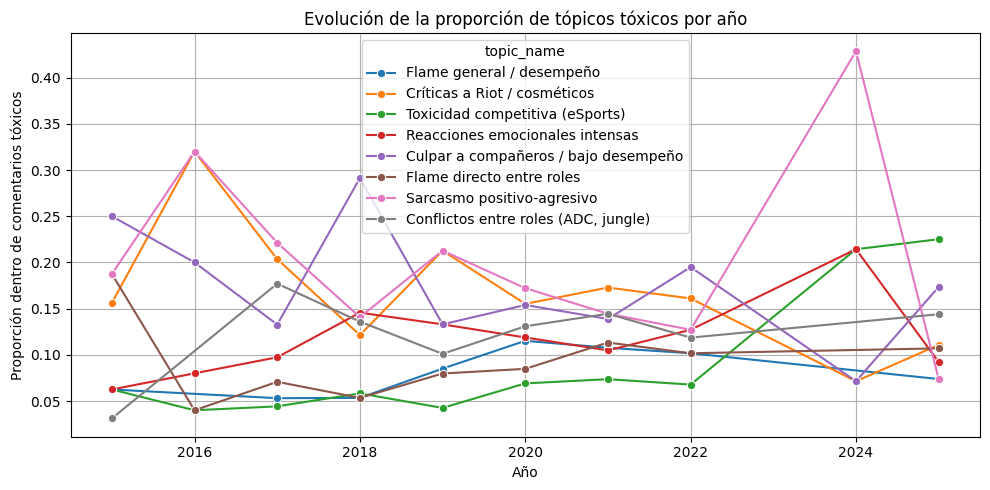

In [11]:
df_topics = pd.read_csv(DATA_PROCESSED / "reddit_toxic_with_topics.csv")


# Diccionario de nombres interpretativos de tópicos
topic_labels = {
    0: "Flame general / desempeño",
    1: "Críticas a Riot / cosméticos",
    2: "Toxicidad competitiva (eSports)",
    3: "Reacciones emocionales intensas",
    4: "Culpar a compañeros / bajo desempeño",
    5: "Flame directo entre roles",
    6: "Sarcasmo positivo-agresivo",
    7: "Conflictos entre roles (ADC, jungle)"
}

# Asegurar tipos
df_topics["year"] = df_topics["year"].astype(int)
df_topics["topic_id"] = df_topics["topic_id"].astype(int)

# Contar comentarios por año y tópico
topic_year = (
    df_topics.groupby(["year", "topic_id"])
             .size()
             .reset_index(name="count")
)

# Proporción dentro del año
topic_year["prop"] = topic_year["count"] / topic_year.groupby("year")["count"].transform("sum")

# Agregar nombre interpretativo
topic_year["topic_name"] = topic_year["topic_id"].map(topic_labels)

# Graficar usando topic_name
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=topic_year,
    x="year",
    y="prop",
    hue="topic_name",
    marker="o"
)

plt.title("Evolución de la proporción de tópicos tóxicos por año")
plt.xlabel("Año")
plt.ylabel("Proporción dentro de comentarios tóxicos")
plt.grid(True)
plt.tight_layout()
plt.show()
